# Grid Field Heatmaps

This notebook is a finer-resolution sibling of `Region_Field_Heatmaps.ipynb`. Instead of
painting each **watershed region** with the mean value of the points mapped to it, it
paints every **X&times;X-pixel block** of the underlying UMAP density/watershed grid with
the mean value of whatever points fall inside that block &mdash; i.e. spatial resolution
goes below the region level, down to (a coarsened version of) the same pixel grid
`zVals_wShed_groups.mat`'s region map (`LL`) and density estimate live on.

As in `Region_Field_Heatmaps.ipynb`, this computes the **mean value** of several sensor
fields &mdash; CO&#8322; (averaged over the sensor channels present), relative humidity,
activity and ambient temperature &mdash; plus a wavelet-derived "most meaningful
timeframe" field, and renders each as a heatmap over the UMAP embedding. Watershed region
boundaries are overlaid (thin black lines) purely for visual reference against the
familiar region map &mdash; region identity itself plays no role in the computation here.

**Prerequisite:** same as `Region_Field_Heatmaps.ipynb` &mdash; the target project must
already have gone through the watershed step of `Ethogram_Generation_Metabolism.ipynb`
(i.e. `UMAP/zVals_wShed_groups.mat` must exist), and the per-dataset raw dataframes must
be cached in `Results/Intermediate_Results/*.pkl`. This notebook does not re-download any
data or re-run PCA/UMAP/watershed &mdash; it only reloads what that pipeline already
computed and saved, plus each dataset's own 2D UMAP coordinates
(`Projections/{source_id}_pcaModes_uVals.mat`) to place points on the fine grid.

Kernel: `motionmapper37` (same as `Ethogram_Generation_Metabolism.ipynb` and
`Region_Field_Heatmaps.ipynb`).

## 1.&nbsp; Imports

In [14]:
import glob, os, pickle, re, sys
from pathlib import Path

sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCThermalPlots/RHCImaging')
sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCThermalPlots')
sys.path.append('Metabolism/VisualActivity/RHCVisualisation')
sys.path.append('Metabolism/VisualActivity')
sys.path.append('Metabolism')
sys.path.insert(0, os.path.abspath('motionmapperpy-master'))

import hdf5storage
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

from umap_video_utils import load_watershed_artifacts
from umap_interp_utils import _load_wavelet_data, _characteristic_period_minutes
from utils import reconstruct_whole_hive
%matplotlib inline

## 2.&nbsp; Configuration

In [15]:
# Path to the motionmapperpy project directory (same one used in Ethogram_Generation_Metabolism.ipynb
# and Region_Field_Heatmaps.ipynb)
projectPath = r"/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivityWholeHiveNewTiming/"
intermediate_dir = "Results/Intermediate_Results"

# Fine-grid resolution: each output cell aggregates a PIXEL_BLOCK_SIZE x PIXEL_BLOCK_SIZE block
# of pixels from the *same* underlying density/watershed-label grid used by
# Region_Field_Heatmaps.ipynb (that grid is `LL`/`density`/`xx` in zVals_wShed_groups.mat, e.g.
# 611x611 pixels covering the full UMAP extent -- see Section 6). A block of 1 pixel would
# reproduce that grid's own native resolution; larger blocks trade spatial detail for fewer,
# less noisy cells. Cells with fewer than MIN_POINTS_PER_CELL points are left blank (NaN)
# rather than plotted from a handful of possibly-unrepresentative points.
PIXEL_BLOCK_SIZE = 10
MIN_POINTS_PER_CELL = 3

# Display option (Section 10): fill blank/insufficiently-populated cells by interpolating from
# that same watershed region's own populated cells, never crossing into a neighboring region.
# This turns each region into one continuously-filled shape with an internal gradient instead of
# a speckled patchwork of gaps -- "regions still look uniform" (as a filled shape) while still
# showing the finer-than-region variation within them. Purely cosmetic: cell_means /
# cell_period_hours (the actual per-cell statistics) and the saved point counts are untouched;
# only what gets plotted in Section 10 changes. Set to False to see the raw, unfilled fine grid.
INTERPOLATE_WITHIN_REGIONS = False

PROJECT_DIR = Path(projectPath)
PROJECTIONS_DIR = PROJECT_DIR / "Projections"

# parameters.pkl records which method (UMAP/TSNE) and project path were used to build the
# watershed run, so we load it instead of hard-coding the method.
with open(PROJECT_DIR / "parameters.pkl", "rb") as f:
    parameters = pickle.load(f)

UMAP_DIR = PROJECT_DIR / parameters.method
WSHED_PATH = UMAP_DIR / "zVals_wShed_groups.mat"
assert WSHED_PATH.exists(), f"Watershed file not found at {WSHED_PATH}. Run the watershed step of Ethogram_Generation_Metabolism.ipynb first."
print(f"Project: {PROJECT_DIR}")
print(f"Method : {parameters.method}")
print(f"Watershed file: {WSHED_PATH}")

# pipeline_config.pkl (only saved by newer runs of Ethogram_Generation.ipynb) is the
# authoritative record of which raw columns actually fed this project's PCA/UMAP -- unlike
# Results/Intermediate_Results/*.pkl, which is a *shared*, mutable cache that different
# projects' runs (with different only_ambT/include_activity/whole_hive settings) all merge
# columns into over time, so a column being present there doesn't mean this project used it.
# Section 8 uses this, when available, to select fields instead of guessing from cache contents.
pipeline_config_path = PROJECT_DIR / "pipeline_config.pkl"
if pipeline_config_path.exists():
    with open(pipeline_config_path, "rb") as f:
        pipeline_config = pickle.load(f)
    print("\nLoaded pipeline_config.pkl -- authoritative record of this project's inputs:")
    for k, v in pipeline_config.items():
        print(f"  {k}: {v}")
else:
    pipeline_config = None
    print(
        "\nNo pipeline_config.pkl found for this project (that bookkeeping was only added to "
        "Ethogram_Generation.ipynb after this project was generated). Section 8 will fall back "
        "to inferring which fields to plot from whichever columns happen to be present in "
        "df_nat -- if in doubt about what this project's pipeline actually used, check the "
        "generating notebook's config at the relevant commit (e.g. via git history/timestamps) "
        "rather than trusting the cache."
    )

Project: /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivityWholeHiveNewTiming
Method : UMAP
Watershed file: /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivityWholeHiveNewTiming/UMAP/zVals_wShed_groups.mat

Loaded pipeline_config.pkl -- authoritative record of this project's inputs:
  used_exp_list: ['SharpDay', 'SharpNight', 'SoftDay', 'SoftNight', 'Idle', 'Constant', 'Observation']
  required_keys: [('Constant', 2), ('Idle', 1), ('Idle', 2), ('Observation', 1), ('Observation', 2), ('SharpDay', 1), ('SharpDay', 2), ('SharpNight', 1), ('SharpNight', 2), ('SoftDay', 1), ('SoftDay', 2), ('SoftNight', 1)]
  resolution: 600
  only_ambT: True
  include_temperature: False
  include_activity: True
  whole_hive: True
  WideNormalisation: True
  variance_threshold: 0.99
  min_regions: 10


## 3.&nbsp; Load per-dataset raw data

Dataset identity is taken directly from the `*_pcaModes.mat` files present in
`Projections/`, i.e. exactly the datasets that went into the current watershed run &mdash;
not from the experiment config, so this stays correct even if `used_exp_list` changes in
the source notebook. This works for both single-IHL runs (`{exp}_hive{hive_nb}_{ihl}`,
e.g. `Observation_hive1_upper`) and whole-hive runs (`{exp}_hive{hive_nb}`, both ihls
combined, e.g. `Observation_hive1`) &mdash; see `whole_hive` in
`Ethogram_Generation.ipynb`.

In [16]:
dataset_id_pattern = re.compile(r"^(?P<exp>.+)_hive(?P<hive>\d+)(?:_(?P<ihl>upper|lower))?$")


def _source_id(key):
    """Rebuild the exact string used to name this dataset's *_pcaModes.mat file.

    key is (exp, hive_nb, ihl); ihl is None for a whole-hive (both ihls combined) run --
    same convention as _source_id() in Ethogram_Generation.ipynb.
    """
    exp, hive_nb, ihl = key
    return f"{exp}_hive{hive_nb}" if ihl is None else f"{exp}_hive{hive_nb}_{ihl}"


dataset_keys = []  # list of (exp, hive_nb, ihl); ihl=None for a whole-hive dataset
for pca_file in sorted(PROJECTIONS_DIR.glob("*_pcaModes.mat")):
    source_id = pca_file.name[: -len("_pcaModes.mat")]
    m = dataset_id_pattern.match(source_id)
    if not m:
        print(f"Skipping unrecognized projection file name: {pca_file.name}")
        continue
    dataset_keys.append((m.group("exp"), int(m.group("hive")), m.group("ihl")))

print(f"Found {len(dataset_keys)} datasets in {PROJECTIONS_DIR}:")
for key in dataset_keys:
    print(" ", key, f"(source_id={_source_id(key)})")

Found 12 datasets in /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivityWholeHiveNewTiming/Projections:
  ('Constant', 2, None) (source_id=Constant_hive2)
  ('Idle', 1, None) (source_id=Idle_hive1)
  ('Idle', 2, None) (source_id=Idle_hive2)
  ('Observation', 1, None) (source_id=Observation_hive1)
  ('Observation', 2, None) (source_id=Observation_hive2)
  ('SharpDay', 1, None) (source_id=SharpDay_hive1)
  ('SharpDay', 2, None) (source_id=SharpDay_hive2)
  ('SharpNight', 1, None) (source_id=SharpNight_hive1)
  ('SharpNight', 2, None) (source_id=SharpNight_hive2)
  ('SoftDay', 1, None) (source_id=SoftDay_hive1)
  ('SoftDay', 2, None) (source_id=SoftDay_hive2)
  ('SoftNight', 1, None) (source_id=SoftNight_hive1)


In [17]:
exps_dfs = {}
for key in dataset_keys:
    exp, hive_nb, ihl = key
    source_id = _source_id(key)
    pkl_path = os.path.join(intermediate_dir, f"{source_id}.pkl")

    if os.path.exists(pkl_path):
        with open(pkl_path, "rb") as f:
            exps_dfs[key] = pickle.load(f)
    elif ihl is None:
        # No hive-level pickle cached directly -- if both ihls were already cached separately
        # (e.g. from an earlier single-IHL run), reconstruct the whole-hive dataset from them
        # instead, same fallback as the dataset-loading section of Ethogram_Generation.ipynb.
        upper_path = os.path.join(intermediate_dir, f"{exp}_hive{hive_nb}_upper.pkl")
        lower_path = os.path.join(intermediate_dir, f"{exp}_hive{hive_nb}_lower.pkl")
        assert os.path.exists(upper_path) and os.path.exists(lower_path), (
            f"Missing cached dataset {pkl_path}, and no {upper_path}/{lower_path} pair to "
            f"reconstruct it from. Run the dataset-loading section of Ethogram_Generation.ipynb "
            f"(with save_files=True) first."
        )
        with open(upper_path, "rb") as f:
            upper_df = pickle.load(f)
        with open(lower_path, "rb") as f:
            lower_df = pickle.load(f)

        has_temp_grid = any(re.match(r"^t\d+$", c) for c in upper_df.columns) and any(
            re.match(r"^t\d+$", c) for c in lower_df.columns
        )
        exps_dfs[key] = reconstruct_whole_hive(upper_df, lower_df, only_amb_T=not has_temp_grid)
        print(f"Reconstructed {source_id} from cached {exp}_hive{hive_nb}_upper/lower pickles.")
    else:
        raise AssertionError(
            f"Missing cached dataset {pkl_path}. Run the dataset-loading section of "
            f"Ethogram_Generation.ipynb (with save_files=True) first."
        )
    print(f"Loaded {source_id}: {exps_dfs[key].shape}")

Loaded Constant_hive2: (419, 6)
Loaded Idle_hive1: (1475, 6)
Loaded Idle_hive2: (1351, 6)
Loaded Observation_hive1: (7232, 134)
Loaded Observation_hive2: (3491, 134)
Loaded SharpDay_hive1: (1526, 6)
Loaded SharpDay_hive2: (1233, 6)
Loaded SharpNight_hive1: (1988, 6)
Loaded SharpNight_hive2: (981, 6)
Loaded SoftDay_hive1: (1871, 6)
Loaded SoftDay_hive2: (1217, 6)
Loaded SoftNight_hive1: (2193, 6)


## 4.&nbsp; Interpolate short gaps

Same gap-filling as `Region_Field_Heatmaps.ipynb`: linearly interpolate short NaN gaps
(`limit=6` samples). This does not determine *which rows exist* &mdash; Section 5 uses
each dataset's own `real_timestamps` (saved alongside its embeddings in
`Projections/{source_id}_pcaModes.mat`) as the authoritative row set, and just reindexes
this interpolated dataframe onto those exact timestamps to look up feature values.

In [18]:
exps_dfs_interp = {}
for key, df in exps_dfs.items():
    df = df.astype(float)
    df = df.interpolate(method='time', limit=6, limit_direction='both')
    exps_dfs_interp[key] = df

    # Diagnostic only -- no longer used to determine the row set (Section 5 uses each
    # dataset's own real_timestamps for that).
    n_would_survive_dropna = len(df.dropna(how='any'))
    print(f"{key}: {len(df)} rows after interpolation ({n_would_survive_dropna} would survive a dropna(how='any'))")

('Constant', 2, None): 419 rows after interpolation (419 would survive a dropna(how='any'))
('Idle', 1, None): 1475 rows after interpolation (1475 would survive a dropna(how='any'))
('Idle', 2, None): 1351 rows after interpolation (1351 would survive a dropna(how='any'))
('Observation', 1, None): 7232 rows after interpolation (4213 would survive a dropna(how='any'))
('Observation', 2, None): 3491 rows after interpolation (2003 would survive a dropna(how='any'))
('SharpDay', 1, None): 1526 rows after interpolation (1526 would survive a dropna(how='any'))
('SharpDay', 2, None): 1233 rows after interpolation (1233 would survive a dropna(how='any'))
('SharpNight', 1, None): 1988 rows after interpolation (1988 would survive a dropna(how='any'))
('SharpNight', 2, None): 981 rows after interpolation (981 would survive a dropna(how='any'))
('SoftDay', 1, None): 1871 rows after interpolation (1871 would survive a dropna(how='any'))
('SoftDay', 2, None): 1217 rows after interpolation (1191 would

## 5.&nbsp; Build the per-point dataframe (`df_nat`)

One row per timepoint in each dataset's own `real_timestamps` (loaded from
`Projections/{source_id}_pcaModes.mat`, the same array `findEmbeddings` was run on) &mdash;
this is the authoritative row set, not whatever `interpolate(...).dropna(...)` happens to
reproduce (see Section 4). Each dataset's interpolated dataframe is `reindex`ed onto its
`real_timestamps`; any timestamp not recoverable from the cached/interpolated raw data
becomes a row of NaN feature values rather than a dropped row. Tagged with `source_id`
and real timestamp, same as `Region_Field_Heatmaps.ipynb`.

In [19]:
# real_timestamps_by_source: source_id -> full real_timestamps array (tz-aware UTC), exactly
# as saved by findEmbeddings, NOT yet filtered by keptIdx. Section 7 reuses this dict (instead
# of re-reading each dataset's *_pcaModes.mat a second time) and indexes into it with keptIdx.
real_timestamps_by_source = {}
df_nat = []
for key, df in exps_dfs_interp.items():
    source_id = _source_id(key)
    pca_file = PROJECTIONS_DIR / f"{source_id}_pcaModes.mat"
    pca_data = hdf5storage.loadmat(str(pca_file))
    real_ts = pd.to_datetime(np.asarray(pca_data["real_timestamps"]).squeeze(), utc=True)
    assert real_ts.is_unique, f"{source_id}: real_timestamps contains duplicate timestamps -- can't use as a row index."
    real_timestamps_by_source[source_id] = real_ts

    # real_ts is the authoritative row set for this dataset (exactly what findEmbeddings was
    # fed at generation time) -- reindex onto it instead of trusting whatever row set
    # interpolate+dropna happens to produce here. Any real_ts row the cached/interpolated data
    # can't fill (gap wider than `limit` can bridge, or the cache missing that window
    # entirely) becomes NaN feature values, not a dropped row.
    df = df.reindex(real_ts)

    n_missing = df.isna().any(axis=1).sum()
    if n_missing:
        print(f"{source_id}: {n_missing}/{len(real_ts)} real_timestamps rows have >=1 NaN "
              f"feature after reindexing onto the interpolated data (kept as NaN rows).")

    df["real_timestamp"] = df.index
    df["source_id"] = source_id
    df_nat.append(df)

df_nat = pd.concat(df_nat, axis=0).sort_index()
print(df_nat.shape)
df_nat.tail()

(19678, 136)


,co2_UL,co2_UR,co2_LL,co2_LR,rel_humid,activity,real_timestamp,source_id,t000,t001,t002,t003,t004,t005,t006,t007,t008,t009,t010,t011,t012,t013,t014,t015,t016,t017,t018,t019,t020,t021,t022,t023,t024,t025,t026,t027,t028,t029,t030,t031,t032,t033,t034,t035,t036,t037,t038,t039,t040,t041,t042,t043,t044,t045,t046,t047,t048,t049,t050,t051,t052,t053,t054,t055,t056,t057,t058,t059,t060,t061,t062,t063,t064,t065,t066,t067,t068,t069,t070,t071,t072,t073,t074,t075,t076,t077,t078,t079,t080,t081,t082,t083,t084,t085,t086,t087,t088,t089,t090,t091,t092,t093,t094,t095,t096,t097,t098,t099,t100,t101,t102,t103,t104,t105,t106,t107,t108,t109,t110,t111,t112,t113,t114,t115,t116,t117,t118,t119,t120,t121,t122,t123,t124,t125,t126,t127
2025-01-19 15:20:00+00:00,3251.0,1005.0,2991.0,912.0,45.708705,0.056813,2025-01-19 15:20:00+00:00,SoftDay_hive1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-19 15:30:00+00:00,3583.0,1275.0,3213.0,1132.0,45.893413,0.057763,2025-01-19 15:30:00+00:00,SoftDay_hive1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-19 15:40:00+00:00,3964.0,1560.0,3610.0,1362.0,46.214371,0.058714,2025-01-19 15:40:00+00:00,SoftDay_hive1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-19 15:50:00+00:00,3902.0,1368.0,3606.0,1151.0,45.831307,0.058714,2025-01-19 15:50:00+00:00,SoftDay_hive1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-19 16:00:00+00:00,3722.0,1371.0,3474.0,930.0,46.110662,0.058714,2025-01-19 16:00:00+00:00,SoftDay_hive1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6.&nbsp; Load the watershed/density grid

We need the pixel grid definition (`xx`, the coordinate axis both `LL` and `density`
share along each of their 611 rows/columns in a typical run) that Section 7 coarsens into
fine-grid cells, and the region boundary pixels to overlay on the final heatmaps for
visual reference against the familiar region map. Unlike `Region_Field_Heatmaps.ipynb`,
region identity (`LL`) plays no role in *computing* any statistic here -- but Section 10
optionally uses it to decide which cells belong to the same region, purely to know which
populated cells are allowed to interpolate into which blank ones
(`INTERPOLATE_WITHIN_REGIONS`, Section 2).

Boundary pixels are read directly from `wshed_raw["wbounds"]` rather than via
`load_watershed_artifacts`'s `wbounds` field: that helper assumes `wbounds` is a list of
ordered polygon paths, but `mmpy.wshedTransform`'s own saveplot (see
`Experiment_Density_Heatmaps.ipynb`, Section 4) actually stores it as a `(col_idx,
row_idx)` pair of *pixel*-space edge coordinates from `np.where(roberts(wshed))` -- an
unordered scatter of boundary pixels -- which the generic parser silently returns as
empty for this project's format. Converting those pixel indices through `xx` and
scattering them directly (same approach as `Experiment_Density_Heatmaps.ipynb`) is what
actually draws visible boundaries.

Underlying grid: 611x611 pixels, spacing 0.2226 UMAP units/pixel
PIXEL_BLOCK_SIZE=10 -> 62x62 cells (~2.23x2.23 UMAP units each)
8 watershed regions found: [1, 2, 3, 4, 5, 6, 7, 8]
5040 region-boundary pixels


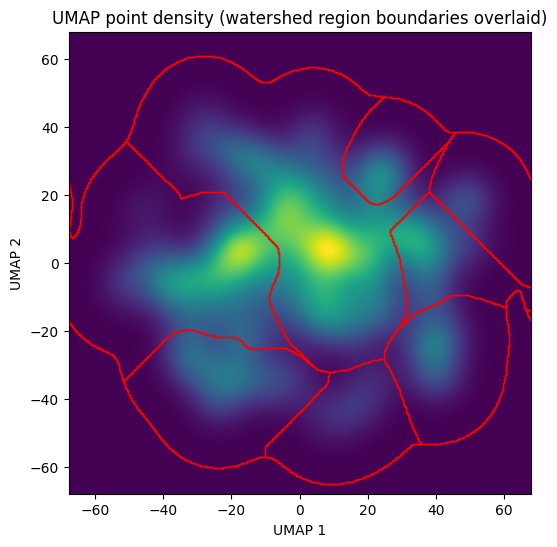

In [20]:
artifacts = load_watershed_artifacts(str(WSHED_PATH))
wshed_raw = hdf5storage.loadmat(str(WSHED_PATH))

xx = artifacts["xx"].squeeze()
extent = artifacts["extent"]

# LL (the watershed region-label image) isn't exposed by load_watershed_artifacts -- only needed
# here for Section 10's optional INTERPOLATE_WITHIN_REGIONS gap filling, not for any statistic.
LL = np.asarray(wshed_raw["LL"])
region_ids = sorted(int(r) for r in np.unique(LL) if r > 0)

# See markdown above: wbounds is a scatter of boundary-pixel indices, not polygon paths -- this
# is the same conversion Experiment_Density_Heatmaps.ipynb uses to actually render it.
wb_raw = wshed_raw["wbounds"]
boundary_x = xx[np.asarray(wb_raw[0, 0]).ravel().astype(int)]
boundary_y = xx[np.asarray(wb_raw[0, 1]).ravel().astype(int)]

grid_n = len(xx)                 # number of pixels per side of the underlying density/label grid
pixel_spacing = xx[1] - xx[0]     # UMAP-space units per pixel
n_blocks = int(np.ceil(grid_n / PIXEL_BLOCK_SIZE))
cell_size_umap_units = PIXEL_BLOCK_SIZE * pixel_spacing

print(f"Underlying grid: {grid_n}x{grid_n} pixels, spacing {pixel_spacing:.4f} UMAP units/pixel")
print(f"PIXEL_BLOCK_SIZE={PIXEL_BLOCK_SIZE} -> {n_blocks}x{n_blocks} cells "
      f"(~{cell_size_umap_units:.2f}x{cell_size_umap_units:.2f} UMAP units each)")
print(f"{len(region_ids)} watershed regions found: {region_ids}")
print(f"{len(boundary_x)} region-boundary pixels")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(artifacts["density"], origin='lower', extent=extent, cmap='viridis')
ax.scatter(boundary_x, boundary_y, s=1.5, color="red", alpha=0.9, linewidths=0)
ax.set_title("UMAP point density (watershed region boundaries overlaid)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.show()

## 7.&nbsp; Map each row of `df_nat` to a fine-grid cell

For each dataset, each kept point's 2D UMAP coordinate is saved in
`Projections/{source_id}_pcaModes_uVals.mat` (`zValues`), row-for-row aligned with
`outputStatistics.keptIdx` &mdash; i.e. `zValues[i]` is the embedding of
`real_timestamps[keptIdx[i]]`, exactly the same alignment guarantee
`Region_Field_Heatmaps.ipynb` relies on for `watershedRegions`. We convert each point's
continuous `(x, y)` into a pixel index on the same grid `xx` defines (nearest pixel
center), then collapse `PIXEL_BLOCK_SIZE x PIXEL_BLOCK_SIZE` runs of pixels into one
`(cell_row, cell_col)` &mdash; the fine-grid analogue of a watershed region id. Rows are
matched back into `df_nat` by timestamp, same pattern as the region-assignment section of
`Region_Field_Heatmaps.ipynb`.

Per-dataset `(cell_row, cell_col)` arrays are also stashed in `dataset_cells` (in each
dataset's own kept-point order) for reuse in Section 9, where they need to line up
row-for-row with that dataset's saved wavelet amplitudes.

In [21]:
def pixel_index(coord):
    """Nearest-pixel index of a continuous UMAP coordinate on the xx grid, clipped to bounds."""
    idx = np.round((coord - xx[0]) / pixel_spacing).astype(int)
    return np.clip(idx, 0, grid_n - 1)


df_nat["cell_row"] = np.nan
df_nat["cell_col"] = np.nan
dataset_cells = {}  # source_id -> (cell_row_arr, cell_col_arr), in this dataset's own kept-point order

for key in dataset_keys:
    source_id = _source_id(key)
    uvals_file = PROJECTIONS_DIR / f"{source_id}_pcaModes_uVals.mat"
    stats_file = PROJECTIONS_DIR / f"{source_id}_pcaModes_uVals_outputStatistics.pkl"

    zValues = np.asarray(hdf5storage.loadmat(str(uvals_file))["zValues"], dtype=float)

    with open(stats_file, "rb") as hfile:
        outputStatistics = pickle.load(hfile)
    keptIdx = np.asarray(outputStatistics.keptIdx).astype(int).ravel()

    assert zValues.shape[0] == len(keptIdx), (
        f"{source_id}: zValues ({zValues.shape[0]} points) doesn't match keptIdx "
        f"({len(keptIdx)}) -- Projections/ may be stale relative to outputStatistics.pkl."
    )
    # Reuse the full real_timestamps array Section 5 already loaded from this dataset's own
    # *_pcaModes.mat (and used, unfiltered, as df_nat's row set) instead of re-reading the
    # .mat file -- indexing it with keptIdx exactly mirrors what findEmbeddings did.
    real_ts = real_timestamps_by_source[source_id][keptIdx]

    ix = pixel_index(zValues[:, 0])
    iy = pixel_index(zValues[:, 1])
    cell_col = ix // PIXEL_BLOCK_SIZE
    cell_row = iy // PIXEL_BLOCK_SIZE
    dataset_cells[source_id] = (cell_row, cell_col)

    ts_to_row = dict(zip(real_ts, cell_row))
    ts_to_col = dict(zip(real_ts, cell_col))
    mask_source = df_nat["source_id"] == source_id
    df_nat.loc[mask_source, "cell_row"] = df_nat.loc[mask_source, "real_timestamp"].map(ts_to_row)
    df_nat.loc[mask_source, "cell_col"] = df_nat.loc[mask_source, "real_timestamp"].map(ts_to_col)

n_before = len(df_nat)
df_nat = df_nat.dropna(subset=["cell_row", "cell_col"])
df_nat["cell_row"] = df_nat["cell_row"].astype(int)
df_nat["cell_col"] = df_nat["cell_col"].astype(int)
print(f"Assigned a grid cell to {len(df_nat)}/{n_before} rows.")

# By construction (Section 5 built df_nat's row set directly from each dataset's own
# real_timestamps, and ts_to_row/ts_to_col's keys are exactly real_timestamps[keptIdx], a
# subset of that same array), every kept point is guaranteed to find a matching df_nat row.
total_kept = sum(len(rows) for rows, _ in dataset_cells.values())
assert len(df_nat) == total_kept, (
    f"df_nat ({len(df_nat)}) and the total number of kept, embedded points ({total_kept}) "
    "should match exactly -- every embedded point should map back to exactly one row."
)

Assigned a grid cell to 16282/19678 rows.


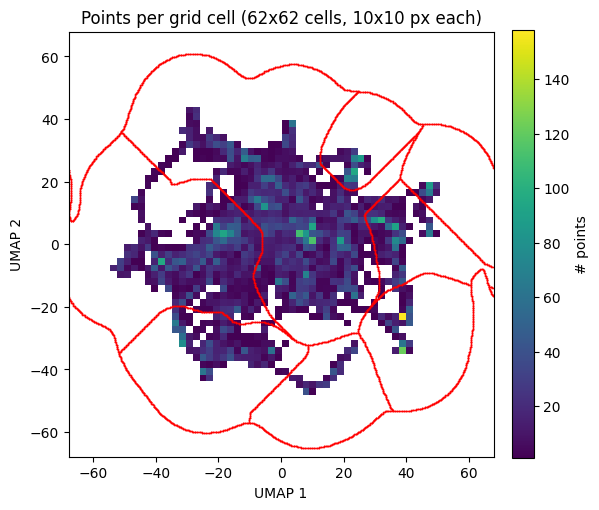

In [22]:
# Sanity check: point density on the fine grid should look like a coarsened version of the
# density map plotted in Section 6.
counts = df_nat.groupby(["cell_row", "cell_col"]).size()
count_grid = np.full((n_blocks, n_blocks), np.nan)
for (r, c), v in counts.items():
    count_grid[r, c] = v

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(count_grid, origin="lower", extent=extent, cmap="viridis")
ax.scatter(boundary_x, boundary_y, s=1.5, color="red", alpha=0.9, linewidths=0)
ax.set_title(f"Points per grid cell ({n_blocks}x{n_blocks} cells, {PIXEL_BLOCK_SIZE}x{PIXEL_BLOCK_SIZE} px each)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="# points")
plt.show()

## 8.&nbsp; Compute per-cell means

Field selection logic is identical to `Region_Field_Heatmaps.ipynb` (see that notebook
for the full rationale): if `pipeline_config.pkl` was found (Section 2), fields are
selected from it directly (asserting the expected columns exist in `df_nat`); otherwise
they're inferred from whichever columns happen to be present in `df_nat`, with each
choice printed explicitly. Mean CO&#8322; is the average of whichever CO&#8322; sensors
are present; activity is stored as a 0-1 fraction and converted to a percentage; relative
humidity is used as-is; temperature is labeled "Ambient temperature" only when the UMAP
was actually trained on `Tamb`, otherwise "Average hive temperature" (mean of the raw
thermal-grid columns).

The only thing that changes from `Region_Field_Heatmaps.ipynb` is the grouping key:
`("cell_row", "cell_col")` instead of `"region"`, and cells with fewer than
`MIN_POINTS_PER_CELL` non-NaN samples for a given field are left as NaN (blank) rather
than plotted from a handful of possibly-unrepresentative points.

In [23]:
FIELDS = {}

co2_channels_whole = ["co2_UL", "co2_UR", "co2_LL", "co2_LR"]
co2_channels_ihl = ["co2_L", "co2_R"]
temp_sensor_cols = sorted(c for c in df_nat.columns if re.match(r"^t\d+$", c))

if pipeline_config is not None:
    # Authoritative path: pipeline_config.pkl records exactly which raw columns this project's
    # PCA/UMAP was built from, so use that instead of guessing from whatever happens to be in
    # the (shared, mutable) Intermediate_Results cache -- and fail loudly if the cache turns out
    # to be missing something the config says should be there, rather than silently skip it.
    co2_channels = co2_channels_whole if pipeline_config.get("whole_hive", False) else co2_channels_ihl
    missing = [c for c in co2_channels if c not in df_nat.columns]
    assert not missing, (
        f"pipeline_config.pkl says whole_hive={pipeline_config.get('whole_hive')}, so this "
        f"project's CO2 input should be {co2_channels}, but {missing} are missing from df_nat "
        f"-- the Intermediate_Results cache looks stale/incomplete for this project."
    )
    df_nat["co2_mean"] = df_nat[co2_channels].mean(axis=1)
    FIELDS["Mean CO2 (ppm)"] = ("co2_mean", "viridis")

    assert "rel_humid" in df_nat.columns, "pipeline_config.pkl expects 'rel_humid', but it's missing from df_nat."
    FIELDS["Relative humidity (%)"] = ("rel_humid", "viridis")

    if pipeline_config.get("include_activity", True):
        assert "activity" in df_nat.columns, (
            "pipeline_config.pkl says include_activity=True, but 'activity' is missing from df_nat."
        )
        df_nat["activity_pct"] = df_nat["activity"] * 100.0
        FIELDS["Activity (%)"] = ("activity_pct", "viridis")
    else:
        print("pipeline_config.pkl: include_activity=False -- skipping the activity heatmap.")

    if not pipeline_config.get("include_temperature", True):
        # Ethogram_Generation_Metabolism.ipynb's include_temperature=False option excludes
        # temperature entirely (no 'Tamb', no per-sensor grid) -- neither branch below would
        # find anything to plot, so skip the field outright instead of asserting.
        print("pipeline_config.pkl: include_temperature=False -- skipping the temperature heatmap.")
    else:
        if "only_ambT" in pipeline_config:
            only_ambT = pipeline_config["only_ambT"]
        else:
            # pipeline_config.pkl files written by Ethogram_Generation_Metabolism.ipynb's save
            # cell never include this key at all -- that notebook hardcodes only_amb_T=True for
            # every download, so it never recorded the setting. Treating a missing key as True
            # is correct specifically for this (Metabolism-notebook) case.
            only_ambT = True
            print(
                "pipeline_config.pkl has no 'only_ambT' key -- this project was generated by "
                "Ethogram_Generation_Metabolism.ipynb, which always used only_amb_T=True; "
                "inferring only_ambT=True."
            )

        if only_ambT:
            # The UMAP was actually trained on Tamb -- a proper ambient-temperature estimate.
            assert "Tamb" in df_nat.columns, "only_ambT=True, but 'Tamb' is missing from df_nat."
            FIELDS["Ambient temperature (C)"] = ("Tamb", "viridis")
        else:
            # The UMAP was trained on the per-sensor thermal grid, NOT Tamb -- so don't label
            # this "ambient temperature". It's the mean of the 64/128 raw thermal-grid sensors
            # instead, a noisier quantity that also picks up bee bodies/hive structure.
            assert temp_sensor_cols, (
                "only_ambT=False, but no per-sensor temperature columns ('tNN...') were found in df_nat."
            )
            df_nat["Tamb_mean"] = df_nat[temp_sensor_cols].mean(axis=1)
            FIELDS["Average hive temperature (C)"] = ("Tamb_mean", "viridis")
else:
    # Heuristic fallback for projects with no pipeline_config.pkl (see Section 2) -- infer
    # fields from whatever columns are present, explicitly printing what was found/used for
    # each so it's at least auditable rather than silent.
    print("No pipeline_config.pkl -- inferring fields from df_nat's columns:")

    if set(co2_channels_whole).issubset(df_nat.columns):
        print(f"  CO2: using {co2_channels_whole} (whole-hive, 4 sensors)")
        df_nat["co2_mean"] = df_nat[co2_channels_whole].mean(axis=1)
        FIELDS["Mean CO2 (ppm)"] = ("co2_mean", "viridis")
    elif set(co2_channels_ihl).issubset(df_nat.columns):
        print(f"  CO2: using {co2_channels_ihl} (single-IHL, 2 sensors)")
        df_nat["co2_mean"] = df_nat[co2_channels_ihl].mean(axis=1)
        FIELDS["Mean CO2 (ppm)"] = ("co2_mean", "viridis")
    else:
        print("  CO2: no recognized CO2 columns found -- skipping the CO2 heatmap.")

    if "rel_humid" in df_nat.columns:
        print("  Humidity: using 'rel_humid'")
        FIELDS["Relative humidity (%)"] = ("rel_humid", "viridis")
    else:
        print("  Humidity: no 'rel_humid' column found -- skipping the humidity heatmap.")

    if "activity" in df_nat.columns:
        print("  Activity: using 'activity'")
        df_nat["activity_pct"] = df_nat["activity"] * 100.0
        FIELDS["Activity (%)"] = ("activity_pct", "viridis")
    else:
        print("  Activity: no 'activity' column found -- skipping the activity heatmap.")

    if "Tamb" in df_nat.columns:
        print("  Temperature: using 'Tamb'")
        FIELDS["Ambient temperature (C)"] = ("Tamb", "viridis")
    elif temp_sensor_cols:
        print(f"  Temperature: no 'Tamb' column -- falling back to mean of {len(temp_sensor_cols)} 'tNN...' sensor columns")
        df_nat["Tamb_mean"] = df_nat[temp_sensor_cols].mean(axis=1)
        FIELDS["Average hive temperature (C)"] = ("Tamb_mean", "viridis")
    else:
        print("  Temperature: no temperature columns found -- skipping the temperature heatmap.")


def cell_group_mean(col):
    """Per-cell mean of df_nat[col], with cells backed by < MIN_POINTS_PER_CELL non-NaN
    samples for this specific column blanked out (NaN) rather than plotted from too little data."""
    grouped = df_nat.groupby(["cell_row", "cell_col"])[col]
    means = grouped.mean()
    counts = grouped.count()
    return means.where(counts >= MIN_POINTS_PER_CELL)


cell_means = {title: cell_group_mean(col) for title, (col, _cmap) in FIELDS.items()}

for title, means in cell_means.items():
    print(f"\n{title}: {means.notna().sum()}/{n_blocks * n_blocks} cells populated")

pipeline_config.pkl: include_temperature=False -- skipping the temperature heatmap.

Mean CO2 (ppm): 773/3844 cells populated

Relative humidity (%): 773/3844 cells populated

Activity (%): 773/3844 cells populated


## 9.&nbsp; Most meaningful timeframe per grid cell (from wavelet coefficients)

Same idea as `Region_Field_Heatmaps.ipynb`'s Section 9, aggregated by grid cell instead of
by region: `findEmbeddings(..., saveWaveletAmps=True)` saves each dataset's Morlet
wavelet amplitude spectrum (one amplitude-vs-period curve per PCA mode, per kept
timepoint) into `Projections/{source_id}_pcaModes_uVals_outputStatistics.pkl`. A
dataset's wavelet amplitude rows share the exact same order as its `dataset_cells` arrays
built in Section 7 (both are computed downstream of the same per-dataset, order-preserving
wavelet &rarr; UMAP-embed pipeline), so we reuse those directly here &mdash; no timestamp
matching needed. We aggregate these per-point spectra into one average spectrum per cell,
then take that spectrum's amplitude-weighted mean period as the cell's characteristic
timescale.

In [24]:
sum_spectrum = {}    # (cell_row, cell_col) -> running sum of mode-summed amplitude spectra
count_spectrum = {}  # (cell_row, cell_col) -> number of points contributing
wavelet_frequencies = None
missing_wavelets = []

for key in dataset_keys:
    source_id = _source_id(key)
    amps, freqs = _load_wavelet_data(source_id, PROJECTIONS_DIR)
    if amps is None:
        missing_wavelets.append(source_id)
        continue

    if wavelet_frequencies is None:
        wavelet_frequencies = freqs
    num_periods = freqs.shape[0]

    cell_row, cell_col = dataset_cells[source_id]
    assert amps.shape[0] == len(cell_row), (
        f"waveletAmplitudes row count ({amps.shape[0]}) doesn't match the number of embedded "
        f"points ({len(cell_row)}) for {source_id}; Projections/ may be stale."
    )
    mode_summed = amps.reshape(len(cell_row), -1, num_periods).sum(axis=1)  # (n_points, numPeriods)

    for i in range(len(cell_row)):
        cell_id = (int(cell_row[i]), int(cell_col[i]))
        sum_spectrum[cell_id] = sum_spectrum.get(cell_id, 0.0) + mode_summed[i]
        count_spectrum[cell_id] = count_spectrum.get(cell_id, 0) + 1

if missing_wavelets:
    print(
        f"No saved waveletAmplitudes for: {missing_wavelets} (skipped -- re-run "
        f"findEmbeddings(..., saveWaveletAmps=True) for these datasets to include them)"
    )

average_spectrum = {
    cell_id: spec / count_spectrum[cell_id]
    for cell_id, spec in sum_spectrum.items()
    if count_spectrum[cell_id] >= MIN_POINTS_PER_CELL
}

cell_period_hours = pd.Series(
    {
        cell_id: _characteristic_period_minutes(spec, wavelet_frequencies) / 60.0
        for cell_id, spec in average_spectrum.items()
    },
    name="characteristic_period_hours",
)
cell_period_hours.index = pd.MultiIndex.from_tuples(cell_period_hours.index, names=["cell_row", "cell_col"])
print(f"Most meaningful timeframe computed for {len(cell_period_hours)}/{n_blocks * n_blocks} cells")
cell_period_hours.describe()

Most meaningful timeframe computed for 773/3844 cells


count    773.000000
mean       7.904875
std        1.527875
min        5.190004
25%        6.690107
50%        7.630288
75%        8.839379
max       12.608172
Name: characteristic_period_hours, dtype: float64

## 10.&nbsp; Heatmaps over the fine grid

Each cell is filled with its mean value for the given field (cells with fewer than
`MIN_POINTS_PER_CELL` points start out blank), and watershed region boundaries are traced
in thin black lines purely for visual reference against the region-level heatmaps in
`Region_Field_Heatmaps.ipynb`. Alongside the sensor fields from Section 8, this also
plots the amplitude-weighted mean wavelet period from Section 9 as one more panel ("most
meaningful timeframe").

When `INTERPOLATE_WITHIN_REGIONS` is `True` (Section 2), blank cells are filled in before
plotting by interpolating from that *same watershed region's own* populated cells --
never crossing into a neighboring region -- so each region reads as one continuously
filled shape with an internal gradient rather than a speckled patchwork of gaps. Each
fine-grid cell is first assigned to whichever region covers the majority of its
underlying pixels (`cell_region`, via `LL` from Section 6); within each region, its blank
cells are filled by linear interpolation from its own populated cells (`scipy.interpolate.
griddata`), falling back to nearest-neighbor for cells outside the convex hull of the
known points (where linear interpolation is undefined). A region with zero populated
cells is left untouched -- there's nothing to interpolate from. This is purely cosmetic:
the underlying `cell_means`/`cell_period_hours` values, and the point counts they're
based on, are never modified -- only what gets drawn changes.

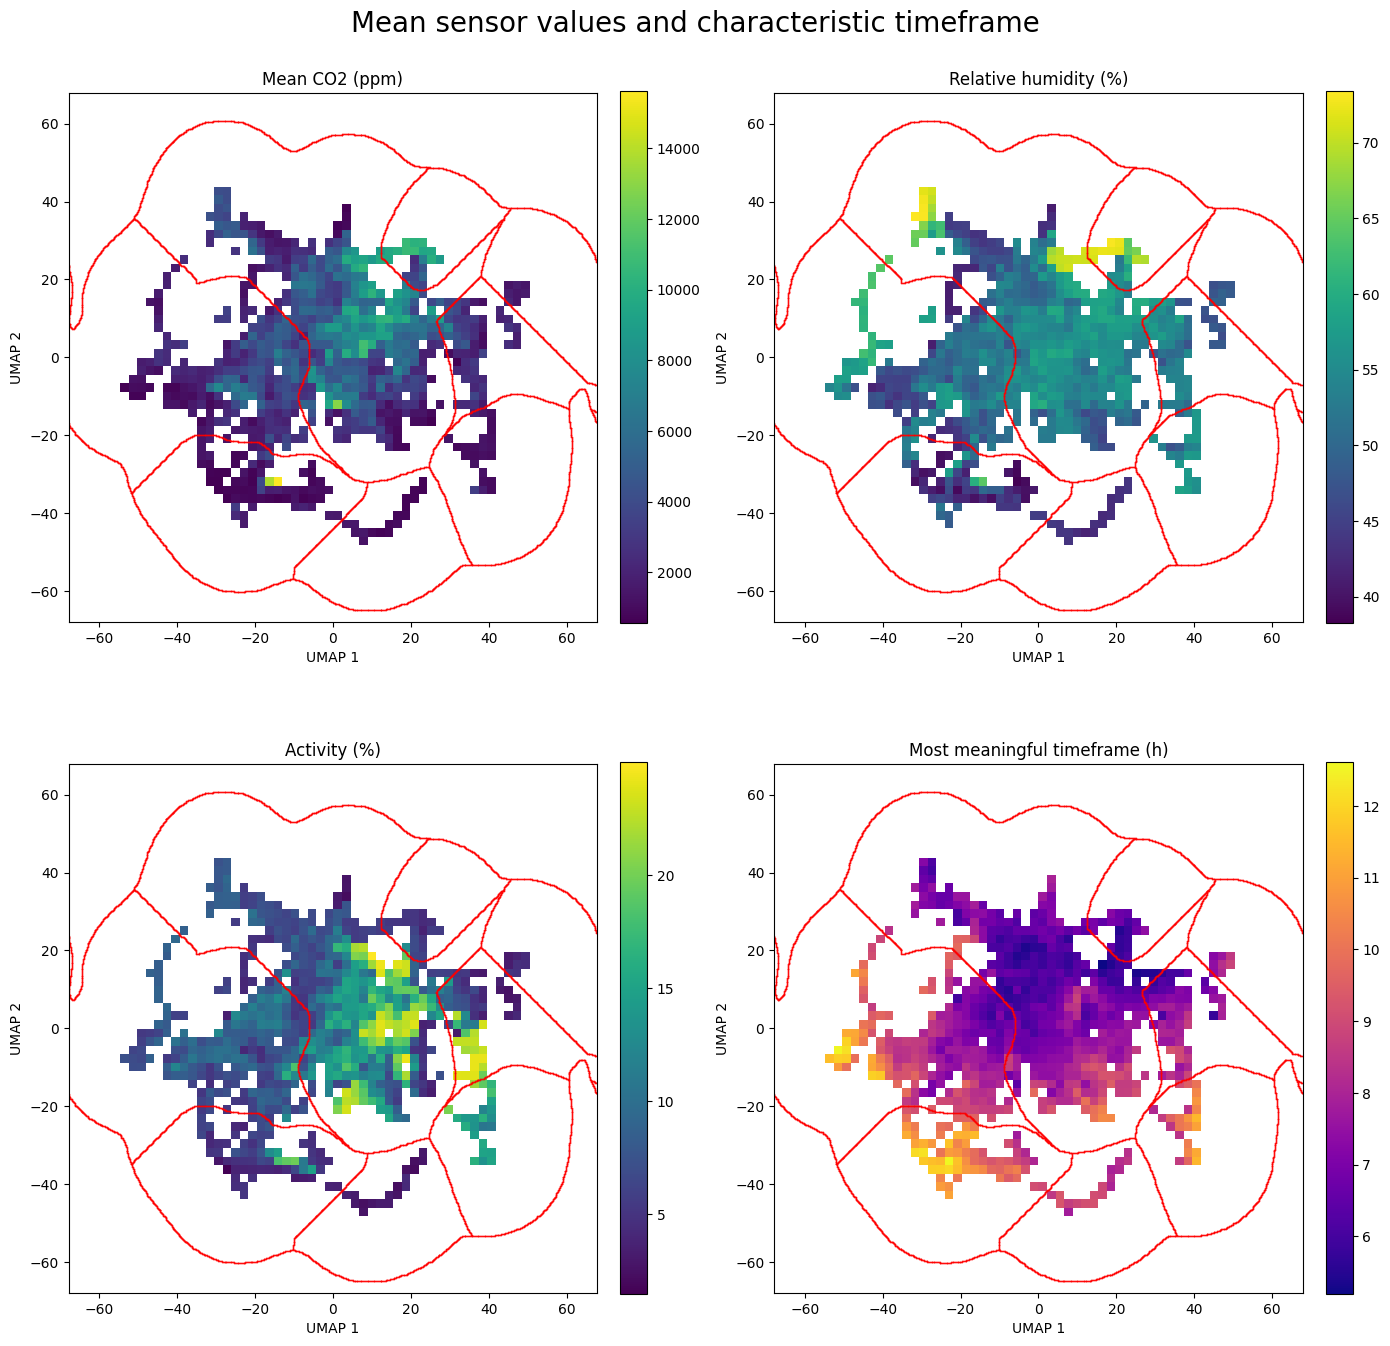

In [25]:
def cells_to_grid(cell_values, n_blocks):
    """cell_values: Series indexed by (cell_row, cell_col) -> value. Returns an
    (n_blocks, n_blocks) array, NaN where no (sufficiently populated) cell exists."""
    H = np.full((n_blocks, n_blocks), np.nan)
    for (r, c), v in cell_values.items():
        H[r, c] = v
    return H


def block_mode_labels(LL, block_size, n_blocks):
    """Downsample the pixel-resolution region-label image LL to the fine grid's own
    resolution: each (row, col) cell gets whichever region id covers the most pixels in its
    block (background/no-region pixels, label 0, are ignored unless a block is 100% background)."""
    grid = np.zeros((n_blocks, n_blocks), dtype=int)
    for r in range(n_blocks):
        for c in range(n_blocks):
            block = LL[r * block_size:(r + 1) * block_size, c * block_size:(c + 1) * block_size]
            vals, counts = np.unique(block, return_counts=True)
            nonzero = vals != 0
            if nonzero.any():
                vals, counts = vals[nonzero], counts[nonzero]
            grid[r, c] = vals[np.argmax(counts)] if len(vals) else 0
    return grid


def interpolate_within_regions(H, cell_region, region_ids):
    """Fill NaN cells of H by interpolating from that same watershed region's own populated
    cells, never crossing into a neighboring region. Falls back to nearest-neighbor for cells
    outside the convex hull of that region's known cells (where linear interpolation is
    undefined). Regions with zero populated cells are left untouched."""
    H_filled = H.copy()
    rows, cols = np.indices(H.shape)
    for rid in region_ids:
        mask = cell_region == rid
        known = mask & ~np.isnan(H)
        unknown = mask & np.isnan(H)
        if known.sum() == 0 or not unknown.any():
            continue
        points = np.column_stack([rows[known], cols[known]])
        values = H[known]
        xi = np.column_stack([rows[unknown], cols[unknown]])
        filled = (
            griddata(points, values, xi, method="linear")
            if known.sum() >= 3
            else np.full(len(xi), np.nan)
        )
        still_nan = np.isnan(filled)
        if still_nan.any():
            filled[still_nan] = griddata(points, values, xi[still_nan], method="nearest")
        H_filled[unknown] = filled
    return H_filled


def plot_grid_heatmap(ax, H, extent, boundary_x, boundary_y, title, cmap):
    im = ax.imshow(H, origin="lower", extent=extent, cmap=cmap, aspect="equal", interpolation="nearest")
    ax.scatter(boundary_x, boundary_y, s=1.5, color="red", alpha=0.9, linewidths=0)
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    fig = ax.get_figure()
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


# Panels to plot: the sensor fields from Section 8, plus the amplitude-weighted mean
# wavelet period per cell from Section 9 ("most meaningful timeframe").
panels = dict(cell_means)
panel_cmaps = {title: cmap for title, (_col, cmap) in FIELDS.items()}
panels["Most meaningful timeframe (h)"] = cell_period_hours
panel_cmaps["Most meaningful timeframe (h)"] = "plasma"

if INTERPOLATE_WITHIN_REGIONS:
    cell_region = block_mode_labels(LL, PIXEL_BLOCK_SIZE, n_blocks)
    region_ids_present = sorted(int(r) for r in np.unique(cell_region) if r > 0)

# Grid sized to however many panels ended up available -- e.g. a whole-hive run with
# include_activity=False and no Tamb column has fewer sensor fields.
n_panels = len(panels)
ncols = 2
nrows = int(np.ceil(n_panels / ncols)) if n_panels else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 7 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax, title in zip(axes_flat, panels):
    H = cells_to_grid(panels[title], n_blocks)
    if INTERPOLATE_WITHIN_REGIONS:
        n_before = np.isfinite(H).sum()
        H = interpolate_within_regions(H, cell_region, region_ids_present)
        print(f"{title}: filled {np.isfinite(H).sum() - n_before} cells via within-region interpolation")
    plot_grid_heatmap(ax, H, extent, boundary_x, boundary_y, title, panel_cmaps[title])

for ax in axes_flat[n_panels:]:
    ax.axis("off")

fig.suptitle("Mean sensor values and characteristic timeframe", fontsize=20)
plt.tight_layout()

# Save figure to project directory
suffix = "_interp" if INTERPOLATE_WITHIN_REGIONS else ""
fig.savefig(PROJECT_DIR / f"grid_field_heatmaps_block{PIXEL_BLOCK_SIZE}{suffix}.png", dpi=300)
plt.show()